In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
warnings.filterwarnings('ignore')

In [ ]:
tested = pd.read_csv('tested.csv')
tested.shape
# (891, 12)

(418, 12)

In [ ]:
tested.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
tested.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

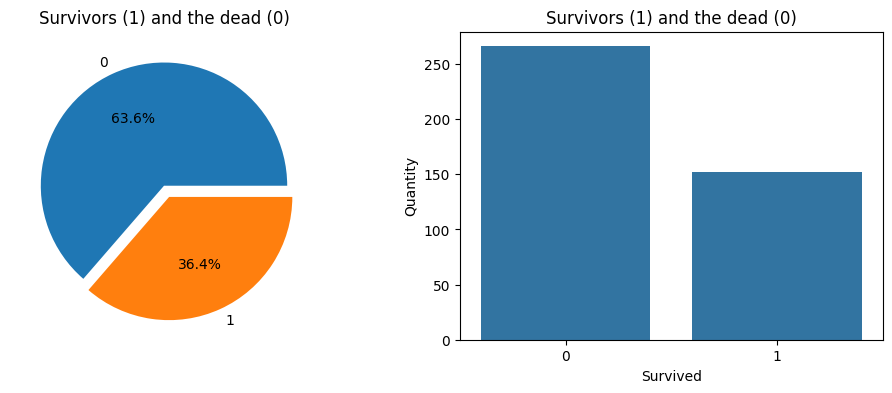

In [ ]:
# visualizing the data
f, ax = plt.subplots(1, 2, figsize=(12, 4))
tested['Survived'].value_counts().plot.pie(
	explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=False)
ax[0].set_title('Survivors (1) and the dead (0)')
ax[0].set_ylabel('')
sns.countplot(x='Survived', data=tested, ax=ax[1])
ax[1].set_ylabel('Quantity')
ax[1].set_title('Survivors (1) and the dead (0)')
plt.show()


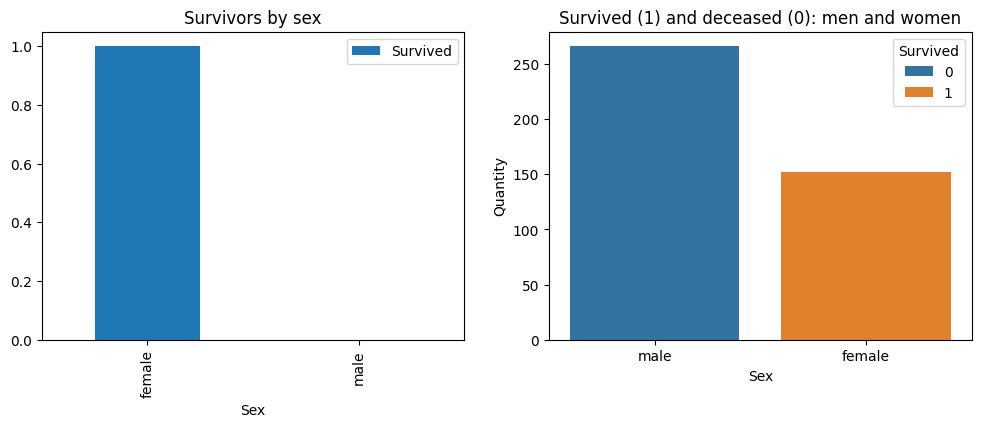

In [ ]:
#analyzing the sex of survived via visulaizing
f, ax = plt.subplots(1, 2, figsize=(12, 4))
tested[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survivors by sex')
sns.countplot(x='Sex', hue='Survived', data=tested, ax=ax[1])
ax[1].set_ylabel('Quantity')
ax[1].set_title('Survived (1) and deceased (0): men and women')
plt.show()


In [ ]:
#performing feature engineering to it
test = tested.drop(['Cabin'],axis=1)

In [ ]:
test = tested.drop(['Ticket'], axis=1)

In [ ]:
test = tested.fillna({"Embarked": "S"})

In [ ]:
# sort the ages into logical categories
tested["Age"] = tested["Age"].fillna(-0.5)
tested["Age"] = tested["Age"].fillna(-0.5)
bins = [-1, 0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager',
          'Student', 'Young Adult', 'Adult', 'Senior']
tested['AgeGroup'] = pd.cut(tested["Age"], bins, labels=labels)
tested['AgeGroup'] = pd.cut(tested["Age"], bins, labels=labels)

In [ ]:
# create a combined group of both datasets
combine = [tested, test]

# extract a title for each Name in the
# tested and test datasets
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

pd.crosstab(tested['Title'], tested['Sex'])

# replace various titles with more common names
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col',
                                                 'Don', 'Dr', 'Major',
                                                 'Rev', 'Jonkheer', 'Dona'],
                                                'Rare')

    dataset['Title'] = dataset['Title'].replace(
        ['Countess', 'Lady', 'Sir'], 'Royal')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

tested[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

# map each of the title groups to a numerical value
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3,
                 "Master": 4, "Royal": 5, "Rare": 6}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

In [ ]:
mr_age = tested[tested["Title"] == 1]["Age"].mode()  # Young Adult
miss_age = tested[tested["Title"] == 2]["Age"].mode()  # Student
mrs_age = tested[tested["Title"] == 3]["Age"].mode()  # Adult
master_age = tested[tested["Title"] == 4]["Age"].mode()  # Baby
royal_age = tested[tested["Title"] == 5]["Age"].mode()  # Adult
rare_age = tested[tested["Title"] == 6]["Age"].mode()  # Adult

age_title_mapping = {1: "Young Adult", 2: "Student",
                     3: "Adult", 4: "Baby", 5: "Adult", 6: "Adult"}

for x in range(len(tested["Age"])):
    if tested["Age"][x] == "Unknown":
        tested["Age"][x] = age_title_mapping[tested["Title"][x]]

for x in range(len(test["Age"])):
    if test["Age"][x] == "Unknown":
        test["Age"][x] = age_title_mapping[test["Title"][x]]

In [ ]:
# map each Age value to a numerical value
age_mapping = {'Baby': 1, 'Child': 2, 'Teenager': 3,
               'Student': 4, 'Young Adult': 5, 'Adult': 6,
               'Senior': 7}
tested['Age'] = tested['Age'].map(age_mapping)
tested['Age'] = test['Age'].map(age_mapping)

tested.head()

# dropping the Age feature for now, might change
test = tested.drop(['Age'], axis=1)

In [ ]:
# train = train.drop(['Name'], axis=1)
test = tested.drop(['Name'], axis=1)

In [ ]:
sex_mapping = {"male": 0, "female": 1}
tested['Sex'] = tested['Sex'].map(sex_mapping)
test['Sex'] = test['Sex'].map(sex_mapping)

embarked_mapping = {"S": 1, "C": 2, "Q": 3}
tested['Embarked'] = tested['Embarked'].map(embarked_mapping)
test['Embarked'] = test['Embarked'].map(embarked_mapping)

In [ ]:
for x in range(len(test["Fare"])):
    if pd.isnull(test["Fare"][x]):
        pclass = test["Pclass"][x]  # Pclass = 3
        test["Fare"][x] = round(
            tested[tested["Pclass"] == pclass]["Fare"].mean(), 4)

# map Fare values into groups of
# numerical values
tested['FareBand'] = pd.qcut(tested['Fare'], 4,
                            labels=[1, 2, 3, 4])
test['FareBand'] = pd.qcut(test['Fare'], 4,
                           labels=[1, 2, 3, 4])

# drop Fare values
# train = tested.drop(['Fare'], axis=1)
test = test.drop(['Fare'], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

# Drop the Survived and PassengerId
# column from the trainset
predictors = tested.drop(['Survived', 'PassengerId'], axis=1)
target = tested["Survived"]
x_train, x_val, y_train, y_val = train_test_split(
    predictors, target, test_size=0.2, random_state=0)

In [ ]:
# Fill missing Fare
for pclass in test["Pclass"].unique():
    mean_fare = tested[tested["Pclass"] == pclass]["Fare"].mean()
    test.loc[(test["Fare"].isnull()) & (test["Pclass"] == pclass), "Fare"] = round(mean_fare, 4)

# Create FareBand
tested['FareBand'] = pd.qcut(tested['Fare'], 4, labels=[1, 2, 3, 4])
test['FareBand'] = pd.qcut(test['Fare'], 4, labels=[1, 2, 3, 4])

# Drop Fare
tested = tested.drop("Fare", axis=1)
test = test.drop("Fare", axis=1)

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
for col in ["Sex", "Embarked", "AgeGroup", "Title"]:
    tested[col] = label.fit_transform(tested[col])
    test[col] = label.transform(test[col])

# Train/test split
from sklearn.model_selection import train_test_split
predictors = tested.drop(["Survived", "PassengerId"], axis=1)
target = tested["Survived"]
x_train, x_val, y_train, y_val = train_test_split(predictors, target, test_size=0.2, random_state=0)

# Model training and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

randomforest = RandomForestClassifier()
randomforest.fit(x_train, y_train)
y_pred = randomforest.predict(x_val)
acc_randomforest = round(accuracy_score(y_pred, y_val) * 100, 2)
print(acc_randomforest)


KeyError: 'Fare'